In [1]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_excel("DF_FINAL.xlsx")

df.head()

calles_base = [
        "Calle Alberto Aguilera",
        "Calle Atocha",
        "Calle Gran Vía",
        "Calle Hortaleza",
        "Calle Mayor",
        "Calle Princesa",
        "Paseo Infanta Isabel",
        "Paseo de El Prado"
]

calles_oeste = []

for base in calles_base:
    for col in df.columns:
        if base in col:
            calles_oeste.append(col)

L = 3  # número de lags

X = pd.DataFrame()

for street in calles_oeste:
    for lag in range(1, L + 1):
        X[f"{street}_t-{lag}"] = df[street].shift(lag)

# Variables externas reales
X["AEMET_tmed"] = df["AEMET_tmed"]
X["AEMET_prec"] = df["AEMET_prec"]
X["dia_semana"] = df["dia_semana"]
X["festivo"] = df["festivo"]

# Convertir variables categóricas a numéricas
X["dia_semana"] = X["dia_semana"].map({
    "lunes": 0,
    "martes": 1,
    "miércoles": 2,
    "jueves": 3,
    "viernes": 4,
    "sábado": 5,
    "domingo": 6
})

X["festivo"] = X["festivo"].map({
    "no": 0,
    "sí": 1
})


y_col = [col for col in df.columns if "Calle Princesa" in col][0]
y = df[y_col]

# Limpiar NaNs
X = X.dropna()
y = y.loc[X.index]

In [3]:
# División temporal (80% train, 20% test)
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(X_train.shape, X_test.shape)

(15376, 43) (3845, 43)


In [4]:
with pd.ExcelWriter("dataset_SVR_Princesa.xlsx") as writer:
    X_train.to_excel(writer, sheet_name="X_train")
    X_test.to_excel(writer, sheet_name="X_test")
    y_train.to_excel(writer, sheet_name="y_train")
    y_test.to_excel(writer, sheet_name="y_test")

In [5]:
model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.1,
    gamma="scale"
)

model.fit(X_train_scaled, y_train_scaled)

SVR(C=10)

In [6]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Predicción próxima hora
X_next = X.iloc[[-1]]
X_next_scaled = scaler_X.transform(X_next)

y_next_scaled = model.predict(X_next_scaled)
y_next = scaler_y.inverse_transform(y_next_scaled.reshape(-1, 1)).ravel()

print("Predicción tráfico en Pincesa (N-S) próxima hora:", y_next[0])

Predicción tráfico en Pincesa (N-S) próxima hora: 314.69669787443786


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 36.61
RMSE: 53.83
MAPE: 12.64%


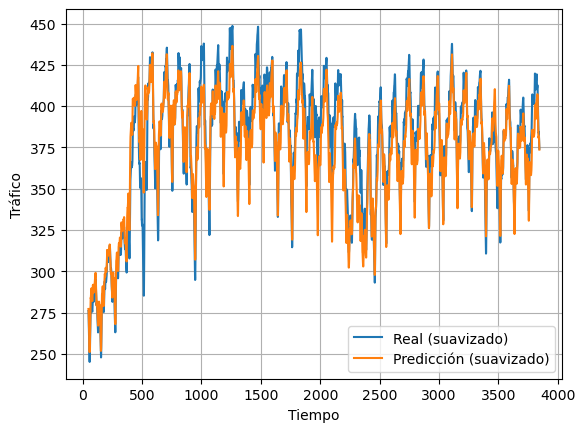

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

y_real_smooth = pd.Series(y_test.values).rolling(window=50).mean()
y_pred_smooth = pd.Series(y_pred).rolling(window=50).mean()

plt.figure()
plt.plot(y_real_smooth, label='Real (suavizado)')
plt.plot(y_pred_smooth, label='Predicción (suavizado)')

plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Tráfico')
plt.grid()

plt.show()